In [1]:
from scipy.stats import gaussian_kde

import matplotlib.pyplot as plt
import numpy as np

-----------------------------------------------------------

In [2]:
import scipy.interpolate as sip
from scipy.optimize import curve_fit

In [4]:
test_files = np.load('../Data/dL_samples.npz')
print(test_files.files)

['LVK_z005', 'LVK_z01', 'LVK_z02', 'CE_z005', 'CE_z01', 'CE_z02', 'CE_z05', 'CE_z075', 'CE_z1', 'CE_z15', 'CE_z2', 'CE_z02_BBH']


In [5]:
dist_names = test_files.files[:-1]

In [6]:
dist_names

['LVK_z005',
 'LVK_z01',
 'LVK_z02',
 'CE_z005',
 'CE_z01',
 'CE_z02',
 'CE_z05',
 'CE_z075',
 'CE_z1',
 'CE_z15',
 'CE_z2']

In [7]:
z_LVK_range = [0.05, 0.1, 0.2]
z_CE_range = [0.05, 0.1, 0.2, 0.5, 0.75, 1.0, 1.5, 2.0]

In [8]:
def renormalise_dist_posterior(sample_name, N_draw):
    dist_samples = test_files[sample_name]

    # Re-weight weights
    p_values = (dist_samples**-2)/np.sum(dist_samples**-2)

    # Choose distance samples indices, based on weights
    indices_all = np.arange(0, len(dist_samples))
    indices_selected = np.random.choice(indices_all, size=N_draw, replace=True, p=p_values)
    
    ## The normalised samples
    DL_normed = dist_samples[indices_selected]
    
    # Calculate kde
    kde_normed = gaussian_kde(DL_normed)

    return DL_normed, kde_normed

In [9]:
def quantile_range(array, q_min, q_max):
    value_min = np.quantile(array, q_min)
    value_max = np.quantile(array, q_max)
    
    return value_max-value_min

In [10]:
## Create the fitting function
def func_quad(x, a0, a1, a2):
    return a0 + a1*x + a2*x**2

def func_lin(x, a0, a1):
    return a0+a1*x

**LVK samples**

In [11]:
N_draw_samples = 2000
dL_res = int(5e3)
data_files = dist_names[:3]

dL_array = np.zeros((len(data_files), N_draw_samples))
dL_kdes = np.zeros((len(data_files), dL_res))

dL_range = np.linspace(0, 2500, dL_res)

for idx, name in enumerate(data_files):
    dL_array[idx, :], dL_kde = renormalise_dist_posterior(name, N_draw_samples)
    dL_kdes[idx, :] = dL_kde(dL_range)

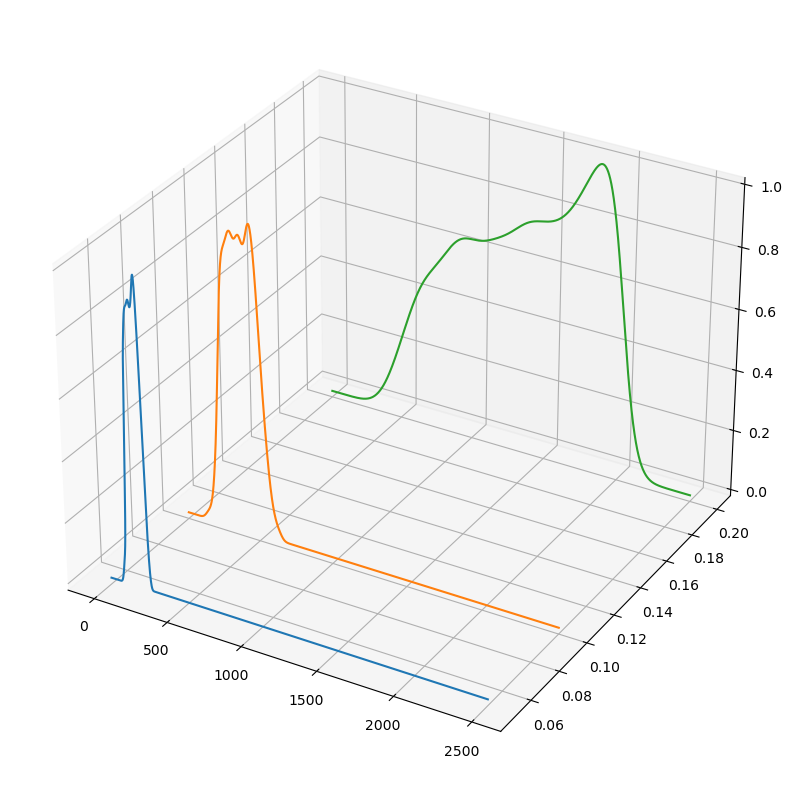

In [12]:
fig = plt.figure(figsize = (14, 10))
ax = fig.add_subplot(111, projection = '3d')

ax.plot(dL_range, np.repeat(0.05, repeats=len(dL_range)), dL_kdes[0, :]/np.max(dL_kdes[0, :]))
ax.plot(dL_range, np.repeat(0.1, repeats=len(dL_range)), dL_kdes[1, :]/np.max(dL_kdes[1, :]))
ax.plot(dL_range, np.repeat(0.2, repeats=len(dL_range)), dL_kdes[2, :]/np.max(dL_kdes[2, :]))

plt.show()

In [98]:
dL_error_LVK = np.zeros(3)  # based on std
dL_range_LVK = np.zeros(3)  # based on quantile range

for i in range(3):
    dL_error_LVK[i] = np.std(dL_array[i, :])/np.median(dL_array[i, :])*100
    dL_range_LVK[i] = quantile_range(dL_array[i, :], 0.158, 0.842)/2/np.median(dL_array[i, :])*100
    print("std based error: ", dL_error_LVK[i], "and median based error: ", dL_range_LVK[i])

std based error:  20.277898216469268 and median based error:  22.901673337908587
std based error:  25.42480752120549 and median based error:  27.350706435828982
std based error:  30.673025795437393 and median based error:  35.06030735043591


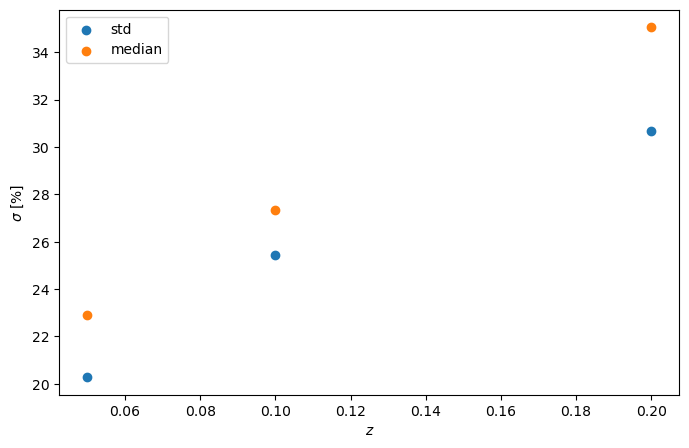

In [99]:
fig = plt.figure(figsize=(8, 5))
ax1 = fig.add_subplot(1, 1, 1)

ax1.scatter(z_LVK_range, dL_error_LVK, label='std')
ax1.scatter(z_LVK_range, dL_range_LVK, label='median')

ax1.set_xlabel(r'$z$')
ax1.set_ylabel(r'$\sigma$ [%]')
ax1.legend()

plt.show()

**Standard deviations**

In [147]:
## Create the interpolation
sigma_interp = sip.interp1d(z_LVK_range, dL_error_LVK, kind='quadratic')

## Test the interpolation for a range of sigma values
z_detailed = np.linspace(0.05, 0.2, 80)
sigma_interpolation = sigma_interp(z_detailed)

In [148]:
popt_LVK, pcov_LVK = curve_fit(func_quad, z_LVK_range, dL_error_LVK)
popt_lin_LVK, _ = curve_fit(func_lin, z_LVK_range, dL_error_LVK)

/tmp/ipykernel_1433982/3262714969.py:1: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_LVK, pcov_LVK = curve_fit(func_quad, z_LVK_range, dL_error_LVK)


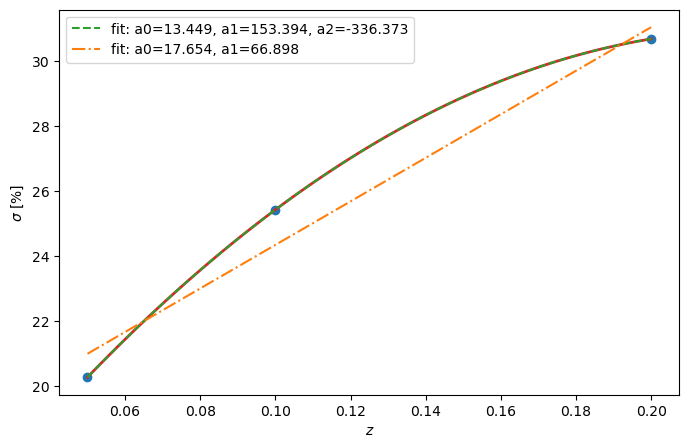

In [149]:
fig = plt.figure(figsize=(8, 5))
ax1 = fig.add_subplot(1, 1, 1)

ax1.scatter(z_LVK_range, dL_error_LVK)
ax1.plot(z_detailed, sigma_interpolation, ls='-', lw=2, c='tab:red')
plt.plot(z_detailed, func_quad(z_detailed, *popt_LVK), ls='--', c='tab:green', label='fit: a0=%5.3f, a1=%5.3f, a2=%5.3f' % tuple(popt_LVK))
plt.plot(z_detailed, func_lin(z_detailed, *popt_lin_LVK), ls='-.', c='tab:orange', label='fit: a0=%5.3f, a1=%5.3f' % tuple(popt_lin_LVK))

ax1.set_xlabel(r'$z$')
ax1.set_ylabel(r'$\sigma$ [%]')
ax1.legend()

plt.show()

**Medians**

In [150]:
## Create the interpolation
sigma_interp = sip.interp1d(z_LVK_range, dL_range_LVK, kind='quadratic')

## Test the interpolation for a range of sigma values
z_detailed = np.linspace(0.05, 0.2, 80)
sigma_interpolation = sigma_interp(z_detailed)

In [151]:
popt_LVK, pcov_LVK = curve_fit(func_quad, z_LVK_range, dL_range_LVK)
popt_lin_LVK, _ = curve_fit(func_lin, z_LVK_range, dL_range_LVK)

/tmp/ipykernel_1433982/2374793773.py:1: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_LVK, pcov_LVK = curve_fit(func_quad, z_LVK_range, dL_range_LVK)


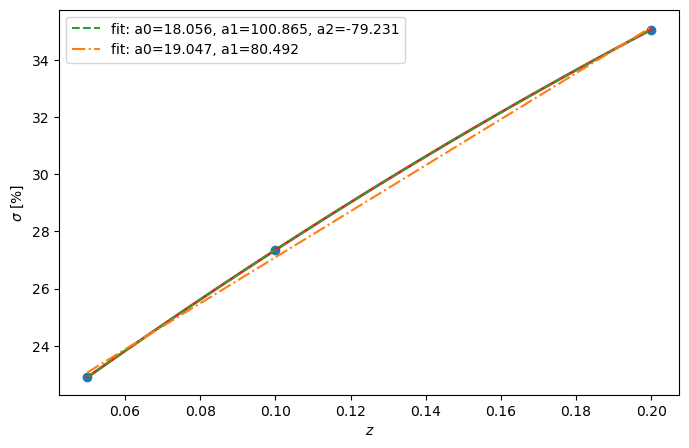

In [152]:
fig = plt.figure(figsize=(8, 5))
ax1 = fig.add_subplot(1, 1, 1)

ax1.scatter(z_LVK_range, dL_range_LVK)
ax1.plot(z_detailed, sigma_interpolation, ls='-', lw=2, c='tab:red')
plt.plot(z_detailed, func_quad(z_detailed, *popt_LVK), ls='--', c='tab:green', label='fit: a0=%5.3f, a1=%5.3f, a2=%5.3f' % tuple(popt_LVK))
plt.plot(z_detailed, func_lin(z_detailed, *popt_lin_LVK), ls='-.', c='tab:orange', label='fit: a0=%5.3f, a1=%5.3f' % tuple(popt_lin_LVK))

ax1.set_xlabel(r'$z$')
ax1.set_ylabel(r'$\sigma$ [%]')
ax1.legend()

plt.show()

**CE samples**

In [119]:
N_draw_samples = 2000
dL_res = int(5e3)
data_files = dist_names[3:]

dL_array = np.zeros((len(data_files), N_draw_samples))
dL_kdes = np.zeros((len(data_files), dL_res))

dL_range = np.linspace(0, 20000, dL_res)

for idx, name in enumerate(data_files):
    dL_array[idx, :], dL_kde = renormalise_dist_posterior(name, N_draw_samples)
    dL_kdes[idx, :] = dL_kde(dL_range)

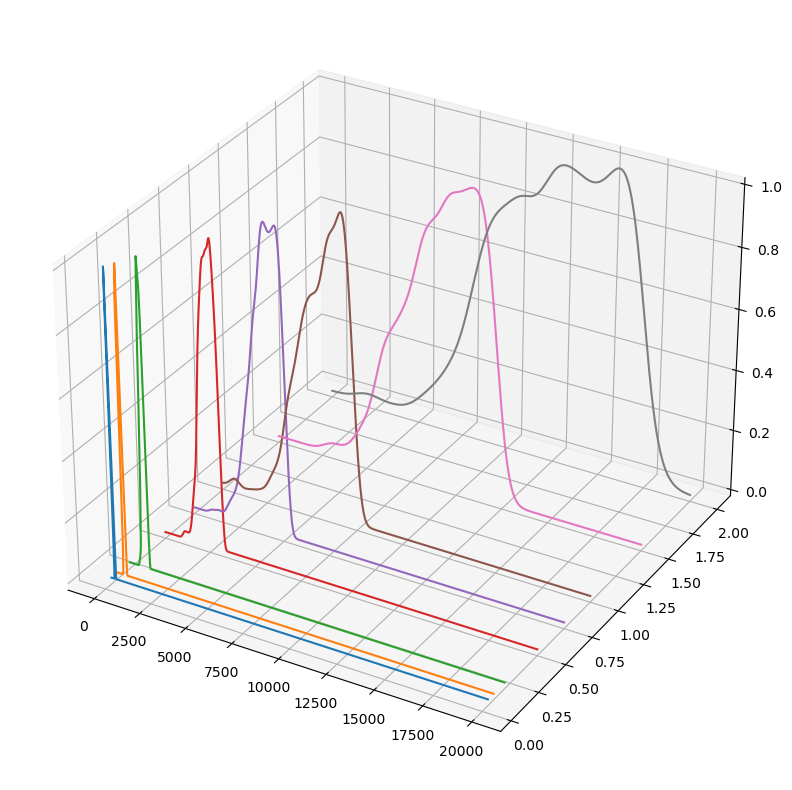

In [120]:
fig = plt.figure(figsize = (14, 10))
ax = fig.add_subplot(111, projection = '3d')

ax.plot(dL_range, np.repeat(0.05, repeats=len(dL_range)), dL_kdes[0, :]/np.max(dL_kdes[0, :]))
ax.plot(dL_range, np.repeat(0.1, repeats=len(dL_range)), dL_kdes[1, :]/np.max(dL_kdes[1, :]))
ax.plot(dL_range, np.repeat(0.2, repeats=len(dL_range)), dL_kdes[2, :]/np.max(dL_kdes[2, :]))
ax.plot(dL_range, np.repeat(0.5, repeats=len(dL_range)), dL_kdes[3, :]/np.max(dL_kdes[3, :]))
ax.plot(dL_range, np.repeat(0.75, repeats=len(dL_range)), dL_kdes[4, :]/np.max(dL_kdes[4, :]))
ax.plot(dL_range, np.repeat(1.0, repeats=len(dL_range)), dL_kdes[5, :]/np.max(dL_kdes[5, :]))
ax.plot(dL_range, np.repeat(1.5, repeats=len(dL_range)), dL_kdes[6, :]/np.max(dL_kdes[6, :]))
ax.plot(dL_range, np.repeat(2.0, repeats=len(dL_range)), dL_kdes[7, :]/np.max(dL_kdes[7, :]))

plt.show()

In [121]:
dL_error_CE = np.zeros(8)
dL_range_CE = np.zeros(8)

for i in range(8):
    dL_error_CE[i] = np.std(dL_array[i, :])/np.median(dL_array[i, :])*100
    dL_range_CE[i] = quantile_range(dL_array[i, :], 0.158, 0.842)/2/np.median(dL_array[i, :])*100    
    print("std based error: ", dL_error_CE[i], "and median based error: ", dL_range_CE[i])

std based error:  6.985813745960928 and median based error:  7.379154501115814
std based error:  8.73805185732904 and median based error:  9.532508932505204
std based error:  11.1530262260407 and median based error:  11.681881078597184
std based error:  16.01900673109412 and median based error:  16.955100465508487
std based error:  18.213736421901682 and median based error:  19.02688729720336
std based error:  21.063454290648707 and median based error:  22.062379311064788
std based error:  21.271775614401907 and median based error:  23.18165882937025
std based error:  24.474474385820812 and median based error:  26.9752489786197


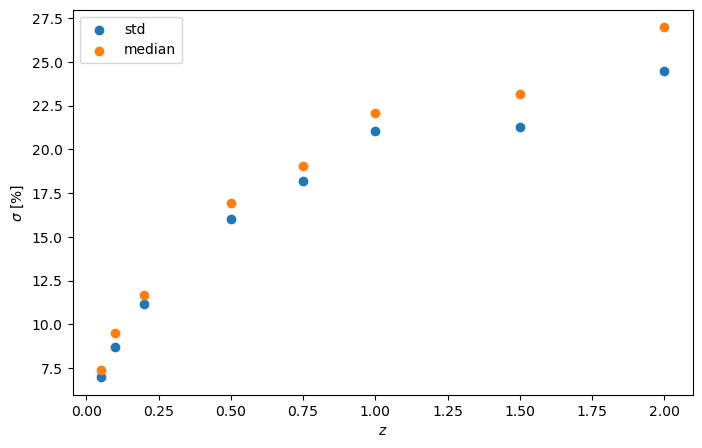

In [122]:
fig = plt.figure(figsize=(8, 5))
ax1 = fig.add_subplot(1, 1, 1)

ax1.scatter(z_CE_range, dL_error_CE, label='std')
ax1.scatter(z_CE_range, dL_range_CE, label='median')

ax1.set_xlabel(r'$z$')
ax1.set_ylabel(r'$\sigma$ [%]')
ax1.legend()

plt.show()

**Standard deviations**

In [138]:
## Create the interpolation
sigma_interp = sip.interp1d(z_CE_range, dL_error_CE, kind=1)

## Test the interpolation for a range of sigma values
z_detailed = np.linspace(0.05, 2.0, 80)
sigma_interpolation = sigma_interp(z_detailed)

In [139]:
popt_CE, pcov_CE = curve_fit(func_quad, z_CE_range, dL_error_CE)
popt_lin_CE, pcov_CE = curve_fit(func_lin, z_CE_range, dL_error_CE)

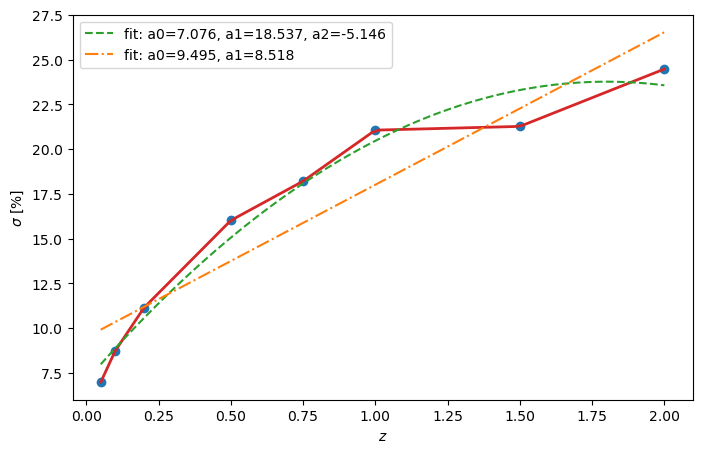

In [140]:
fig = plt.figure(figsize=(8, 5))
ax1 = fig.add_subplot(1, 1, 1)

ax1.scatter(z_CE_range, dL_error_CE)
ax1.plot(z_detailed, sigma_interpolation, ls='-', lw=2, c='tab:red')
plt.plot(z_detailed, func_quad(z_detailed, *popt_CE), ls='--', c='tab:green', label='fit: a0=%5.3f, a1=%5.3f, a2=%5.3f' % tuple(popt_CE))
plt.plot(z_detailed, func_lin(z_detailed, *popt_lin_CE), ls='-.', c='tab:orange', label='fit: a0=%5.3f, a1=%5.3f' % tuple(popt_lin_CE))

ax1.set_xlabel(r'$z$')
ax1.set_ylabel(r'$\sigma$ [%]')
ax1.legend()

plt.show()

**Medians**

In [144]:
## Create the interpolation
sigma_interp = sip.interp1d(z_CE_range, dL_range_CE, kind=1)

## Test the interpolation for a range of sigma values
z_detailed = np.linspace(0.05, 2.0, 80)
sigma_interpolation = sigma_interp(z_detailed)

In [145]:
popt_CE, pcov_CE = curve_fit(func_quad, z_CE_range, dL_range_CE)
popt_lin_CE, pcov_CE = curve_fit(func_lin, z_CE_range, dL_range_CE)

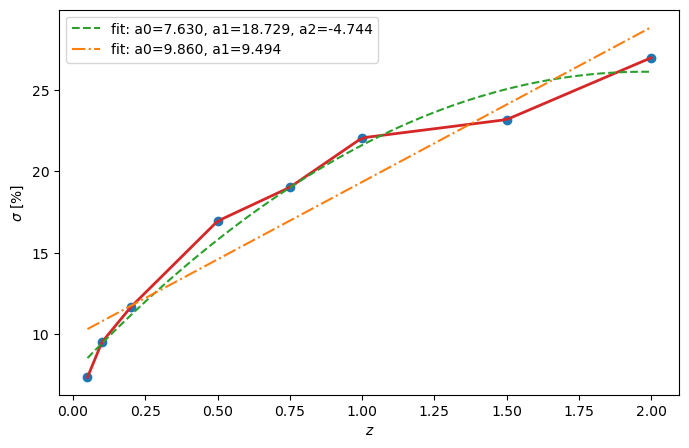

In [146]:
fig = plt.figure(figsize=(8, 5))
ax1 = fig.add_subplot(1, 1, 1)

ax1.scatter(z_CE_range, dL_range_CE)
ax1.plot(z_detailed, sigma_interpolation, ls='-', lw=2, c='tab:red')
plt.plot(z_detailed, func_quad(z_detailed, *popt_CE), ls='--', c='tab:green', label='fit: a0=%5.3f, a1=%5.3f, a2=%5.3f' % tuple(popt_CE))
plt.plot(z_detailed, func_lin(z_detailed, *popt_lin_CE), ls='-.', c='tab:orange', label='fit: a0=%5.3f, a1=%5.3f' % tuple(popt_lin_CE))

ax1.set_xlabel(r'$z$')
ax1.set_ylabel(r'$\sigma$ [%]')
ax1.legend()

plt.show()

*Comparison*

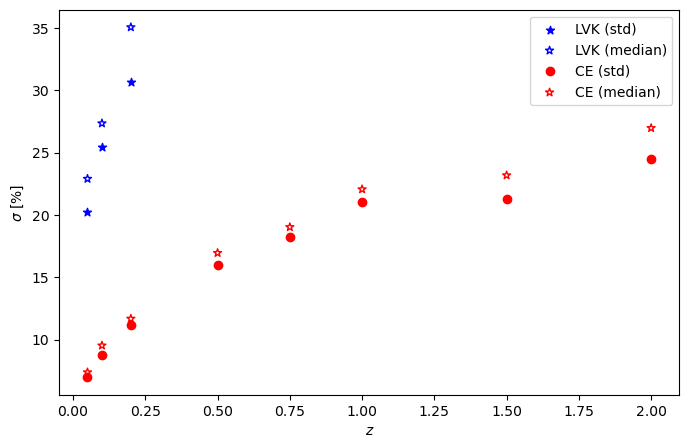

In [158]:
fig = plt.figure(figsize=(8, 5))
ax1 = fig.add_subplot(1, 1, 1)

ax1.scatter(z_LVK_range, dL_error_LVK, marker='*', c='blue', label='LVK (std)')
ax1.scatter(z_LVK_range, dL_range_LVK, marker='*', facecolors='none', edgecolors='blue', label='LVK (median)')
ax1.scatter(z_CE_range, dL_error_CE, c='r', label='CE (std)')
ax1.scatter(z_CE_range, dL_range_CE, marker='*', facecolors='none', edgecolors='red', label='CE (median)')

ax1.set_xlabel(r'$z$')
ax1.set_ylabel(r'$\sigma$ [%]')
ax1.legend()

plt.show()